In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [ ]:
#this code block lets you run your code on your google drive
from google.colab import drive
drive.mount("/content/gdrive")
%cd /content/gdrive/MyDrive

Mounted at /content/gdrive
/content/gdrive/MyDrive


In [ ]:
df =pd.read_csv('fake_news_dataset.csv')

In [ ]:
print(len(df))
print(df.head())
print(df.columns)

4000
   id            title        author  \
0   1  Breaking News 1    Jane Smith   
1   2  Breaking News 2   Emily Davis   
2   3  Breaking News 3      John Doe   
3   4  Breaking News 4  Alex Johnson   
4   5  Breaking News 5   Emily Davis   

                                                text           state  \
0  This is the content of article 1. It contains ...       Tennessee   
1  This is the content of article 2. It contains ...       Wisconsin   
2  This is the content of article 3. It contains ...        Missouri   
3  This is the content of article 4. It contains ...  North Carolina   
4  This is the content of article 5. It contains ...      California   

  date_published          source       category  sentiment_score  word_count  \
0     30-11-2021       The Onion  Entertainment            -0.22        1302   
1     02-09-2021    The Guardian     Technology             0.92         322   
2     13-04-2021  New York Times         Sports             0.25         228   
3

In [ ]:
df = df.drop('title', axis=1)
df = df.drop('id', axis=1)
df = df.drop('text', axis=1)
df = df.drop('author', axis=1)
df = df.drop('date_published', axis=1)
df = df[["clickbait_score", "state", "source", "label", "is_satirical"]]
#df = df.drop('state', axis=1)
scaler = StandardScaler()

In [ ]:

#sns.pairplot(data=df)

In [ ]:
df = pd.get_dummies(df, columns=['state','source','label'], drop_first=True, dtype=int)
print(df.head())
#I think we should get rid of satirical articles, as they are irrelevant to our goals. What does it mean for a satirical article to be real or fake>
print("Num Satirical: ",df["is_satirical"].sum())
#this will eliminate all satirical articles
df = df[df["is_satirical"] != 1]
#this eliminates the is_satirical column now that all entries should be 0
df = df.drop('is_satirical', axis=1)

   clickbait_score  is_satirical  state_California  state_Florida  \
0             0.84             1                 0              0   
1             0.85             1                 0              0   
2             0.72             0                 0              0   
3             0.92             1                 0              0   
4             0.66             0                 1              0   

   state_Georgia  state_Illinois  state_Indiana  state_Maryland  \
0              0               0              0               0   
1              0               0              0               0   
2              0               0              0               0   
3              0               0              0               0   
4              0               0              0               0   

   state_Massachusetts  state_Michigan  ...  source_Fox News  source_HuffPost  \
0                    0               0  ...                0                0   
1                   

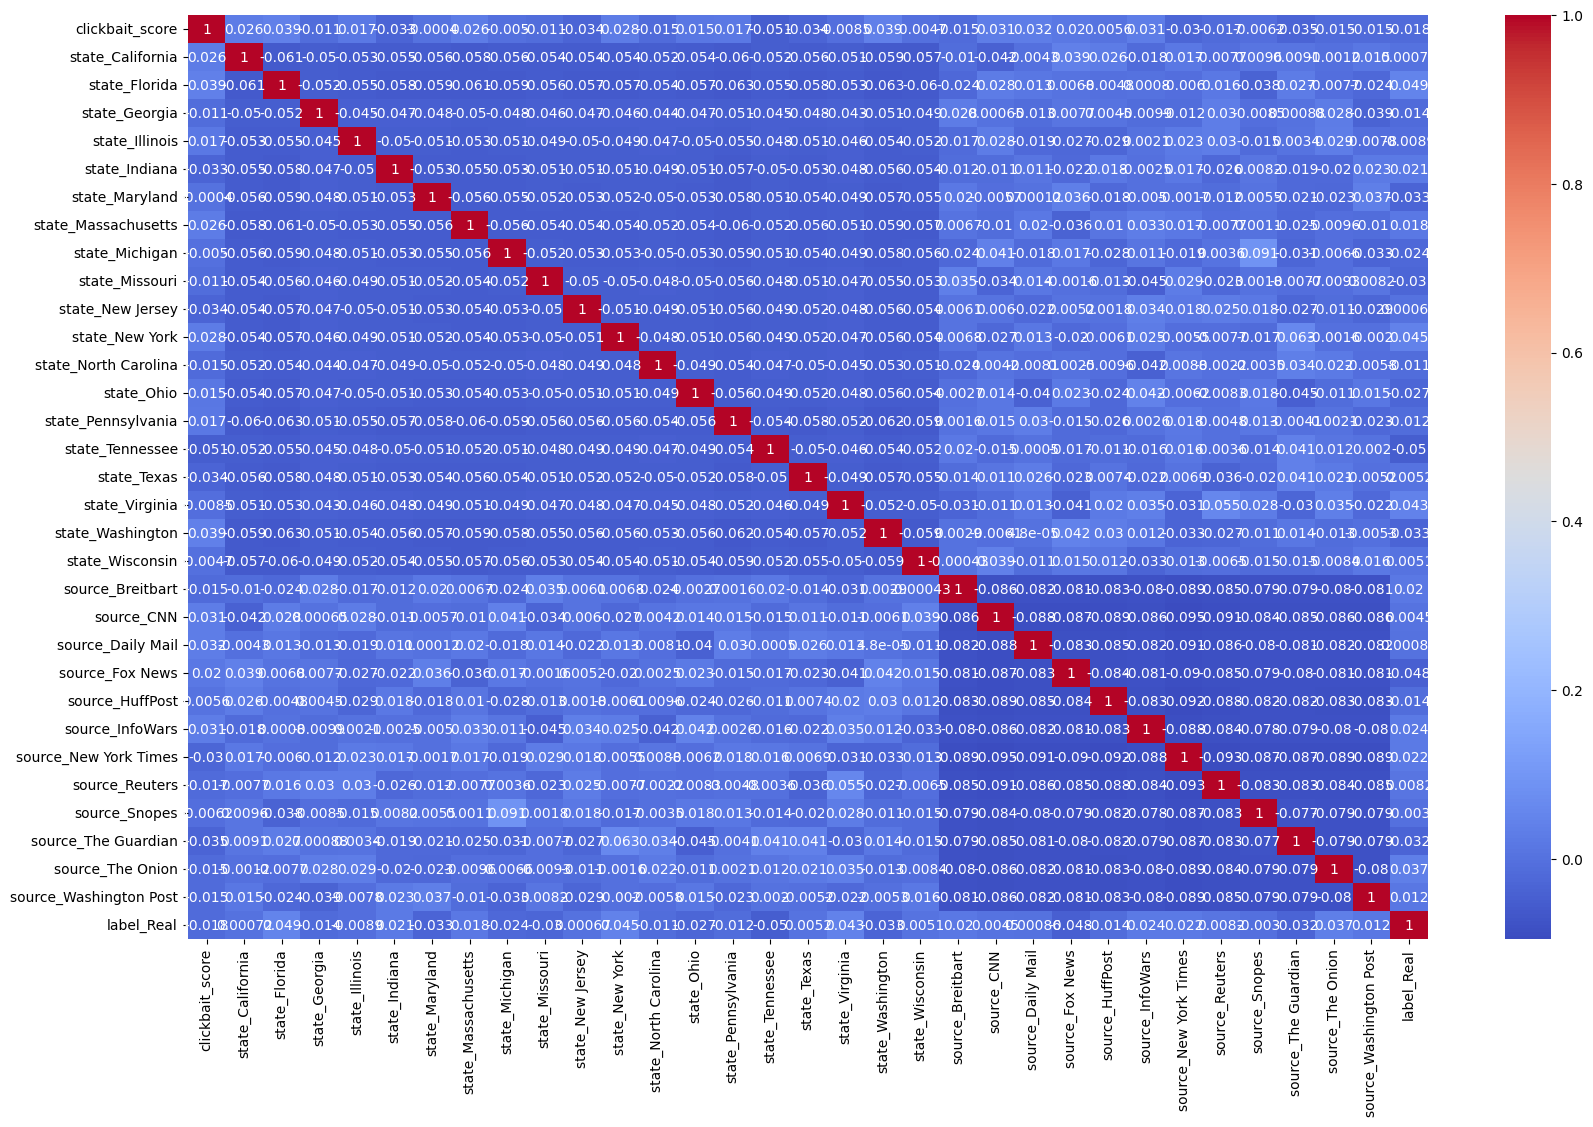

1003


In [ ]:
corr = df.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
print(df["label_Real"].sum())

In [ ]:
print(len(df))
print("Total labelled real: ", df["label_Real"].sum())
#subset = df[['label_Real']]
lr = linear_model.LogisticRegression()
X = df.drop(['label_Real'], axis=1)
y = df['label_Real']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
lr.fit(x_train, y_train)
feature_names = X.columns
standardized_coefficients = pd.Series(lr.coef_[0], index=feature_names).sort_values(ascending=False)
print(standardized_coefficients)
y_pred = lr.predict(x_test)
y_pred_proba = lr.predict_proba(x_test)[:, 1]

2012
Total labelled real:  1003
source_The Onion          0.120859
source_New York Times     0.106120
source_Reuters            0.068675
source_Breitbart          0.049965
source_InfoWars           0.048816
source_CNN                0.042273
source_Washington Post    0.025263
source_Daily Mail         0.014350
source_HuffPost           0.009930
state_Florida            -0.004947
source_Snopes            -0.013478
clickbait_score          -0.033572
state_Indiana            -0.036101
state_New York           -0.051476
source_The Guardian      -0.052674
state_Virginia           -0.060755
source_Fox News          -0.071788
state_Massachusetts      -0.090653
state_Wisconsin          -0.091379
state_California         -0.119273
state_New Jersey         -0.123419
state_Missouri           -0.126867
state_Texas              -0.134683
state_Illinois           -0.136214
state_Pennsylvania       -0.147143
state_Michigan           -0.147343
state_Georgia            -0.159360
state_North Carolina   

In [ ]:
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.5012406947890818
Precision:  0.4782608695652174
Recall:  0.45595854922279794
ROC:  0.5028867505551443


In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.5086848635235732
Precision:  0.48826291079812206
Recall:  0.538860103626943
ROC:  0.5099679249938317


In [ ]:
sv = SVC(probability=True)
sv.fit(x_train, y_train)
y_pred = sv.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.49379652605459057
Precision:  0.4692737430167598
Recall:  0.43523316062176165
ROC:  0.5099679249938317


In [ ]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]
acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
roc = metrics.roc_auc_score(y_test, y_pred_proba)
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("ROC: ", roc)

Accuracy:  0.5384615384615384
Precision:  0.517948717948718
Recall:  0.5233160621761658
ROC:  0.5099679249938317


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:19:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
